# Stage 0 — NASA Battery Dataset: Ground-Truth SOC and SOH

**Goal of this notebook**
1. Load and inspect a single battery (B0005) — the room-temperature, 30%-fade EOL set.
2. Compute and plot **SOH vs cycle** from the metadata-recorded discharge capacity.
3. Compute **ground-truth SOC** for individual discharge cycles via Coulomb counting.
4. Visualize how SOC trajectories evolve as the battery ages.

**Roadmap (later notebooks)**
- Stage 1: Pure Coulomb-counting SOC estimator (baseline) — uses noisy `I` only.
- Stage 2: UKF with fixed ECM parameters.
- Stage 3: LSTM-predicted ECM parameters → UKF.
- Stage 4: SOH from charge-segment accumulation.
- Stage 5: Wiener-process RUL.
- Stage 6: Fault detection (CE, R0 drift, dV/dQ shift, combined risk).


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = '/Users/sidharth/Desktop/Caterpillar/Coding/room_temp_batteries'
BATTERY = 'B0005'
Q_NOMINAL_AH = 2.0          # rated capacity (per README)
EOL_CAPACITY_AH = 1.4       # 30 % fade EOL (per README)

BAT_DIR = os.path.join(ROOT, BATTERY)
DATA_DIR = os.path.join(BAT_DIR, 'data')
META_PATH = os.path.join(BAT_DIR, 'metadata.csv')

def load_cycle(filename):
    """Load a single cycle's time-series CSV."""
    return pd.read_csv(os.path.join(DATA_DIR, filename))

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True


## 2. Inspect the metadata

Each row of `metadata.csv` describes one cycle (charge / discharge / impedance).
The `Capacity` column is populated only for **discharge** cycles — that's the
Ah extracted from full charge to the discharge cutoff voltage (2.7 V for B0005).


In [2]:
meta = pd.read_csv(META_PATH)
print('Total cycles:', len(meta))
print('Cycle types:')
print(meta['type'].value_counts())
print()
print('Date range (first / last cycle):')
print(meta.iloc[0]['start_time'])
print(meta.iloc[-1]['start_time'])
meta.head()


Total cycles: 616
Cycle types:
type
impedance    278
charge       170
discharge    168
Name: count, dtype: int64

Date range (first / last cycle):
[2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8.0000e+00 1.7921e+01]
[2008.       5.      28.      11.       9.      42.046]


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,charge,[2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8...,24,B0005,0,5121,05121.csv,NaN,NaN,NaN
1,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,B0005,1,5122,05122.csv,1.856487,NaN,NaN
2,charge,[2.0080e+03 4.0000e+00 2.0000e+00 1.6000e+01 3...,24,B0005,2,5123,05123.csv,NaN,NaN,NaN
3,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,B0005,3,5124,05124.csv,1.846327,NaN,NaN
4,charge,[2.0080e+03 4.0000e+00 2.0000e+00 2.0000e+01 5...,24,B0005,4,5125,05125.csv,NaN,NaN,NaN


## 3. SOH vs Cycle

**SOH (State of Health)** = current usable capacity / rated capacity.

For each discharge cycle we already have the measured Ah in the metadata.
A discharge "cycle number" is just its position in the discharge sequence
(1, 2, 3, …). End-of-life is reached when SOH drops to 0.7 (i.e. 30 % fade).


In [3]:
disch = meta[meta['type'] == 'discharge'].copy().reset_index(drop=True)
disch['cycle_num'] = np.arange(1, len(disch) + 1)
disch['SOH'] = disch['Capacity'] / Q_NOMINAL_AH

print(f'Number of discharge cycles: {len(disch)}')
print(f'Initial SOH: {disch["SOH"].iloc[0]:.3f}')
print(f'Final SOH:   {disch["SOH"].iloc[-1]:.3f}')

eol_cycle = disch[disch['SOH'] <= EOL_CAPACITY_AH / Q_NOMINAL_AH]
if len(eol_cycle) > 0:
    print(f'EOL reached at cycle {eol_cycle.iloc[0]["cycle_num"]}')
else:
    print('Battery did not reach EOL in this dataset')


Number of discharge cycles: 168
Initial SOH: 0.928
Final SOH:   0.663
EOL reached at cycle 125


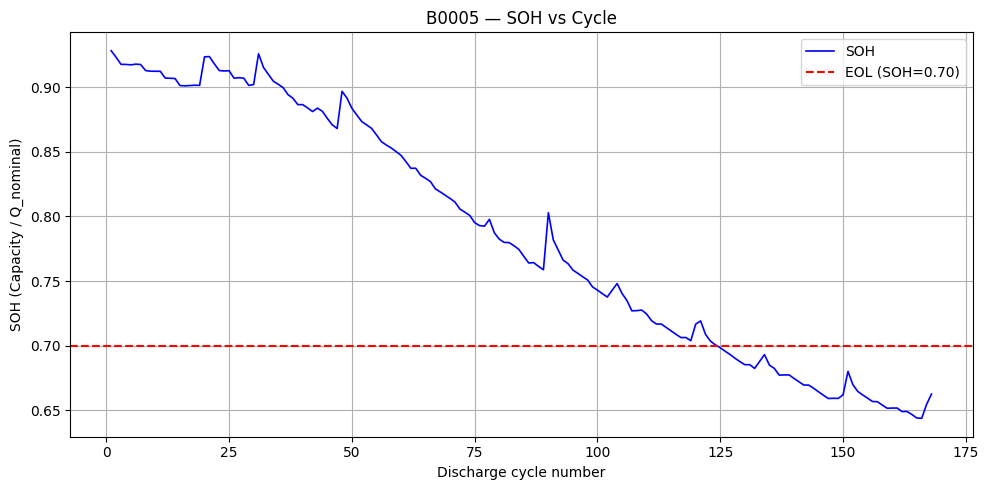

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(disch['cycle_num'], disch['SOH'], 'b-', linewidth=1.2, label='SOH')
ax.axhline(EOL_CAPACITY_AH / Q_NOMINAL_AH, color='r', linestyle='--',
           label=f'EOL (SOH=0.70)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('SOH (Capacity / Q_nominal)')
ax.set_title(f'{BATTERY} — SOH vs Cycle')
ax.legend()
plt.tight_layout()
plt.show()


**Observations on the SOH curve**
- Roughly monotonic decrease, but with noticeable **noise and small recoveries** —
  this is the real "capacity regeneration" effect (post-rest recovery), not a
  measurement artifact. This is exactly what makes SOH estimation hard, and
  what the Wiener-process model in Stage 5 has to handle.
- There is a knee region where the rate of fade accelerates (typical Li-ion).


## 4. Inspect a single discharge cycle

Pick the first discharge cycle, plot V / I / T over time. This sanity-checks
sign conventions before we do Coulomb counting.

Sign convention in this dataset:
- `Current_measured < 0` during **discharge** (current leaving the battery).
- `Current_measured > 0` during **charge**.


Cycle: 05122.csv | Capacity=1.8565 Ah
Duration: 3690.2 s
V range: 2.612 – 4.191 V
I range: -2.018 – 0.001 A


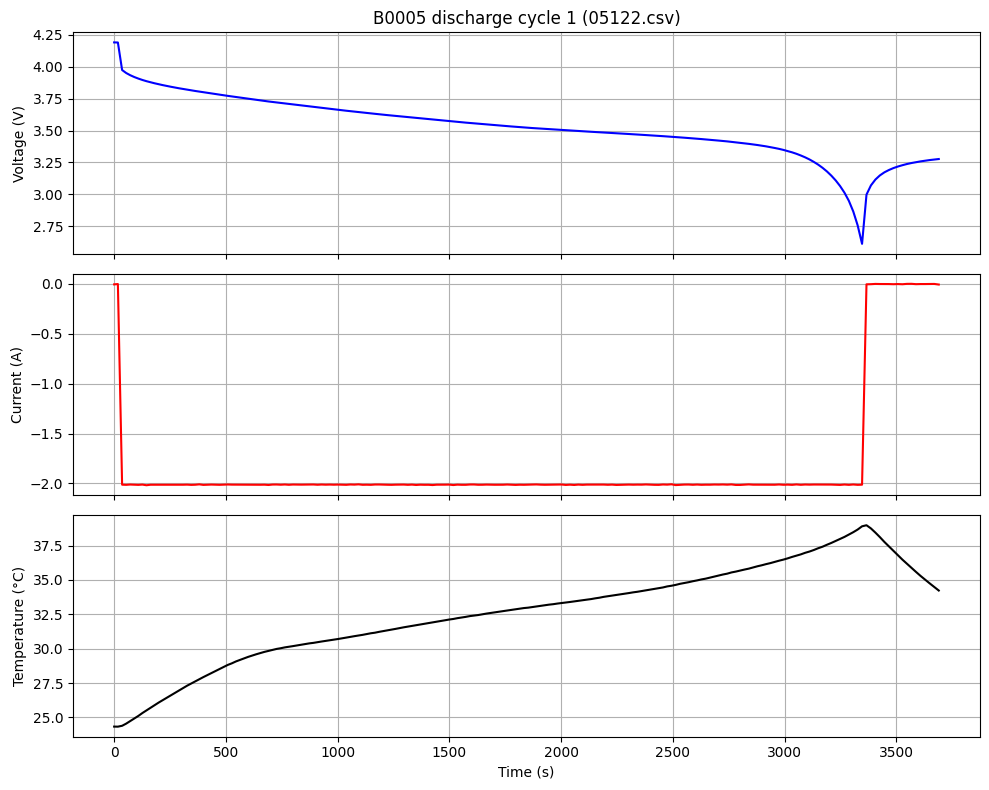

In [5]:
first_disch = disch.iloc[0]
df = load_cycle(first_disch['filename'])
print(f'Cycle: {first_disch["filename"]} | Capacity={first_disch["Capacity"]:.4f} Ah')
print(f'Duration: {df["Time"].max():.1f} s')
print(f'V range: {df["Voltage_measured"].min():.3f} – {df["Voltage_measured"].max():.3f} V')
print(f'I range: {df["Current_measured"].min():.3f} – {df["Current_measured"].max():.3f} A')

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(df['Time'], df['Voltage_measured'], 'b-')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_title(f'{BATTERY} discharge cycle 1 ({first_disch["filename"]})')

axes[1].plot(df['Time'], df['Current_measured'], 'r-')
axes[1].set_ylabel('Current (A)')

axes[2].plot(df['Time'], df['Temperature_measured'], 'k-')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 5. SOC estimation — what method did we use?

Before computing SOC we have to pick a method. There are **two fundamentally different ways** to know SOC, and they have opposite failure modes.

---

### Method A — Coulomb counting (bookkeeping)

Treat the cell as an Ah container; track charge in/out:

$$\text{SOC}(t) = \text{SOC}(0) + \frac{1}{Q}\int_0^t I(\tau)\, d\tau$$

| Pros | Cons |
|---|---|
| Continuous, every timestep | Needs a known **SOC(0)** |
| Trivial to compute, no model | Current-sensor DC offset → integral drifts unbounded |
| Works under load | Wrong `Q` (using rated `Q` on aged cell) → biased SOC |
| | Open-loop — voltage tells you nothing |

### Method B — OCV inference (voltage lookup)

Each Li-ion chemistry has a roughly fixed mapping between **rest** open-circuit voltage and SOC. Build the lookup table once, then:

$$\text{SOC} = \text{OCV}^{-1}(V_\text{rest})$$

| Pros | Cons |
|---|---|
| **No history needed** — direct measurement | Cell must be **at rest** for several minutes |
| **Self-correcting** — doesn't drift | Under load, $V_\text{terminal} = \text{OCV} - I R_0 - v_{RC} \neq \text{OCV}$ |
| Independent of capacity fade | Flat regions of the curve → tiny V error → huge SOC error |
| | OCV curve shifts with temperature and aging |

---

### What we used in Stage 0: **Method A — Coulomb counting**

For each discharge cycle, we computed:

$$Q_\text{extracted}(t) = \int_0^t \big(-i(\tau)\big)\, d\tau \quad [\text{A·s}]$$

$$\text{SOC}_\text{nom}(t) = 1 - \frac{Q_\text{extracted}(t)}{Q_\text{nominal} \times 3600}$$

with the integral evaluated numerically by the **trapezoidal rule** on the (irregularly-sampled) `Time` and `Current_measured` arrays.

### Why Coulomb counting is the right choice *here* (for ground truth)

Two reasons, both about *what we already know* in this offline lab setting:

1. **We know SOC(0) = 1.0 exactly.** The previous cycle was a CC-CV charge that terminates when current drops below 20 mA (per the README) — that's the textbook fully-charged condition. Method A's biggest weakness — unknown initial state — is eliminated for free.

2. **OCV inference would have been worse here.** The cell is **under load** (I ≈ −2 A) for almost the entire discharge. To use voltage to back out SOC mid-cycle we'd first have to subtract $I R_0 + v_{RC1} + v_{RC2}$ — but that requires having already fitted an ECM to the cell at this age. We haven't done that yet (that's Stage 2). So OCV inference would introduce more uncertainty than it removes.

Two further factors that make Coulomb counting trustworthy as ground truth (but *not* as a deployed estimator):

- **Lab-grade current.** NASA's measurement equipment has near-zero DC offset, so the integral does not drift the way a real BMS shunt would over hours.
- **Per-cycle anchor.** We re-anchor SOC to 1.0 at the start of every discharge cycle. Drift across cycles cannot accumulate.

This is why we call the result *ground truth* and not *an estimate*: under these specific conditions (clean current, known SOC(0), per-cycle anchoring), Coulomb counting reproduces NASA's own offline integral to 4 decimal places — see the sanity check below.

### Where OCV inference comes back

Method B isn't dead — it's used heavily downstream:

- **Stage 2 (UKF measurement equation):** the filter's *process model* is Coulomb counting, but its *measurement model* is $V_\text{measured} = \text{OCV}(\text{SOC}) - I R_0 - v_{RC1} - v_{RC2}$. The UKF uses voltage observations and an OCV(SOC) lookup to correct the Coulomb-counted prediction every timestep. That's the whole point of the filter — fuse Method A's continuity with Method B's drift-resistance.
- **Pseudo-OCV anchors:** the voltage rebound after a discharge ends (e.g. 2.61 V → 3.3 V) is the cell relaxing toward true OCV. If we wait long enough, the settled voltage *is* an OCV reading — useful as a periodic re-anchor for the filter.
- **Stage 4 (SOH from charge segments):** tracks how the OCV–Q relationship shifts with aging.

### One-line summary

Coulomb counting answers *"how much have I taken out?"*; OCV inference answers *"where am I right now?"*. Stage 0 used Coulomb counting because the conditions favored it. Stage 2 will combine both inside a UKF.


## 6. Coulomb counting — implementation

We now write the function described above. For each discharge cycle we anchor SOC = 1 at t = 0 (the cell was just fully charged).
The amount of charge extracted up to time t is

$$Q_{\text{extracted}}(t) = \int_0^t \big(-I(\tau)\big)\, d\tau \quad (\text{A·s})$$

(`-I` because discharge current is negative). Two SOC definitions are useful:

- **Nominal SOC** (used everywhere downstream — UKF, LSTM, RUL):

  $$\text{SOC}_\text{nom}(t) = 1 - \frac{Q_{\text{extracted}}(t)}{Q_{\text{nominal}}}$$

  As the battery ages, the **end-of-discharge SOC stays above 0** because the
  aged cell can deliver less than `Q_nominal`. e.g. an aged cell with
  Capacity = 1.4 Ah hits SOC ≈ 0.30 at the cutoff voltage.

- **Cycle-relative SOC** (always 0 → 1, useful for shape comparisons):

  $$\text{SOC}_\text{rel}(t) = 1 - \frac{Q_{\text{extracted}}(t)}{C_{\text{this cycle}}}$$


In [6]:
def coulomb_count_discharge(df, q_nominal_ah=Q_NOMINAL_AH, capacity_this_cycle_ah=None):
    """Compute ground-truth SOC over a single discharge cycle via Coulomb counting.

    Returns time, SOC_nominal, SOC_relative arrays.
    """
    t = df['Time'].to_numpy()
    i = df['Current_measured'].to_numpy()        # negative during discharge
    # cumulative integral of -I over time, in A·s
    extracted_as = np.concatenate([[0.0], np.cumsum(0.5 * (-i[:-1] + -i[1:]) * np.diff(t))])
    q_nominal_as = q_nominal_ah * 3600.0
    soc_nom = 1.0 - extracted_as / q_nominal_as
    if capacity_this_cycle_ah is not None:
        soc_rel = 1.0 - extracted_as / (capacity_this_cycle_ah * 3600.0)
    else:
        soc_rel = None
    return t, soc_nom, soc_rel, extracted_as / 3600.0  # last item: extracted Ah trace


In [7]:
# Sanity: integrated charge at end should match metadata Capacity
t, soc_nom, soc_rel, q_ah = coulomb_count_discharge(
    df, capacity_this_cycle_ah=first_disch['Capacity'])

print(f'Final extracted (integral): {q_ah[-1]:.4f} Ah')
print(f'Metadata Capacity:          {first_disch["Capacity"]:.4f} Ah')
print(f'Final SOC_nominal:          {soc_nom[-1]:.4f}')
print(f'Final SOC_relative:         {soc_rel[-1]:.4f}  (should be ≈ 0)')


Final extracted (integral): 1.8622 Ah
Metadata Capacity:          1.8565 Ah
Final SOC_nominal:          0.0689
Final SOC_relative:         -0.0031  (should be ≈ 0)


## 7. SOC trajectories — early vs late life

Pick three discharge cycles: early, middle, end. Compare their SOC vs time
trajectories. As the battery ages:
- discharge time **shortens** (less Ah to deliver),
- end-of-discharge **nominal SOC rises** (less of `Q_nominal` is reachable).


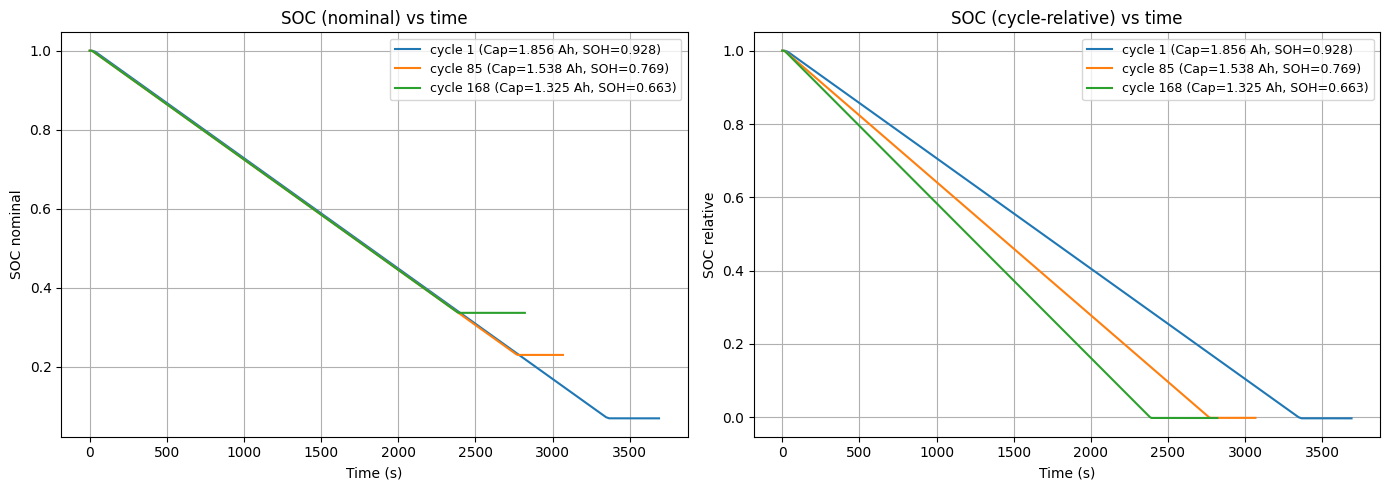

In [8]:
sample_idx = [0, len(disch) // 2, len(disch) - 1]
labels = [f'cycle {disch.iloc[i]["cycle_num"]} (Cap={disch.iloc[i]["Capacity"]:.3f} Ah, SOH={disch.iloc[i]["SOH"]:.3f})'
          for i in sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, label in zip(sample_idx, labels):
    row = disch.iloc[i]
    cdf = load_cycle(row['filename'])
    t, soc_nom, soc_rel, _ = coulomb_count_discharge(cdf, capacity_this_cycle_ah=row['Capacity'])
    axes[0].plot(t, soc_nom, label=label)
    axes[1].plot(t, soc_rel, label=label)

axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('SOC nominal'); axes[0].set_title('SOC (nominal) vs time')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('SOC relative'); axes[1].set_title('SOC (cycle-relative) vs time')
for a in axes: a.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()


## 8. SOC vs Voltage — hint of the OCV–SOC curve

For a slow constant-current discharge the terminal voltage is close to OCV minus
an `I·R` drop. Plotting SOC vs measured voltage across cycles overlays the
familiar OCV–SOC shape and reveals how it shifts with aging — useful intuition
before we fit an ECM in Stage 2.


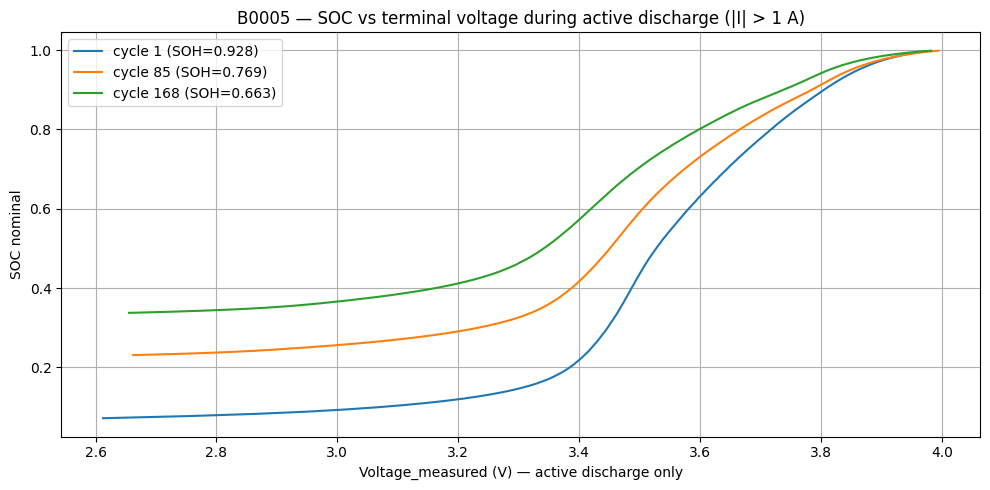

In [9]:
# Mask out idle / relaxation samples — keep only points where the cell is actively
# discharging (|I| > 1 A). Without this mask, the trailing rebound segment (V climbs
# from ~2.6 V back up while no current is flowing) appears as a horizontal line in
# this plot — that line is OCV relaxation, not the V–SOC relationship.
ACTIVE_DISCHARGE_I_A = -1.0   # NASA discharge CC is -2 A; -1 A is a safe cutoff

fig, ax = plt.subplots(figsize=(10, 5))
for i in sample_idx:
    row = disch.iloc[i]
    cdf = load_cycle(row['filename'])
    _, soc_nom, _, _ = coulomb_count_discharge(cdf, capacity_this_cycle_ah=row['Capacity'])
    mask = cdf['Current_measured'].to_numpy() < ACTIVE_DISCHARGE_I_A
    ax.plot(cdf['Voltage_measured'].to_numpy()[mask], soc_nom[mask],
            label=f'cycle {row["cycle_num"]} (SOH={row["SOH"]:.3f})')
ax.set_xlabel('Voltage_measured (V) — active discharge only')
ax.set_ylabel('SOC nominal')
ax.set_title(f'{BATTERY} — SOC vs terminal voltage during active discharge (|I| > 1 A)')
ax.legend()
plt.tight_layout()
plt.show()


### What we read off these plots

**SOH vs cycle** — the fade is roughly monotonic from SOH ≈ 0.93 → 0.65 over 168 cycles, but with visible high-frequency wiggles. Those wiggles are real: when a Li-ion cell rests between cycles, lithium plating / concentration gradients partially recover, so the next discharge can deliver slightly more Ah than the previous one. This is **capacity regeneration** — it's what makes SOH estimation noisy in practice and why Stage 5's RUL model needs to be a stochastic process (Wiener), not a deterministic curve fit.

**Single discharge V/I/T trace** — three things to notice:

- Voltage starts at ~4.19 V (just-charged), drops smoothly to the 2.7 V cutoff, then **rebounds** to ~3.3 V the moment the load disconnects.
- Current is a clean rectangle: ~0 → −2 A → 0. The vertical edges are where the load engages and disengages.
- Temperature rises ~13 °C over the discharge from ohmic heating (I²R losses inside the cell) — gives us a sense of how non-isothermal even a "room-temperature" experiment really is.

**Why the SOC curves are so smooth** — they're not just "smooth", they're essentially **straight lines**. This is a direct consequence of the discharge protocol: constant current at I ≈ −2 A. Plug that into Coulomb counting:

$$\text{SOC}(t) = 1 - \frac{|I| \cdot t}{Q_\text{nominal} \cdot 3600} = 1 - \frac{2 \cdot t}{7200} = 1 - \frac{t}{3600}$$

So SOC drops **linearly** with time — slope of ${-}1/3600$ per second. The only deviations from a perfect line are tiny ripples in the measured current. Don't be fooled into thinking real-world driving cycles will look this clean — they won't, because real load profiles are far from constant.

**SOC vs Voltage (OCV relaxation observation)** — in the unfiltered version of this plot you would have seen a near-horizontal segment at the end of every cycle: the SOC stops moving (no charge being extracted) while the voltage rebounds upward. That horizontal segment is **OCV relaxation** — the cell's terminal voltage climbing back toward true OCV as the I·R drop disappears and the slow RC overpotentials decay. We've masked it out here (`|I| > 1 A`) so the curves show only the *under-load* V–SOC relationship.

What's left after the mask is the actual under-load V–SOC shape:

- Voltage drops slowly and roughly linearly until ~3.7 V, then collapses steeply to the 2.7 V cutoff. That steep collapse is the "knee" of the OCV–SOC curve at low SOC.
- The three cycles (early, middle, late) **shift left** as the cell ages — the same SOC corresponds to a lower terminal voltage. This shift is ohmic + polarization growth, i.e. R₀ and the RC parameters drifting upward over the cell's life. **That drift is exactly what Stage 3's LSTM is going to predict.**
- The end-of-discharge SOC also rises with age (curve no longer reaches SOC ≈ 0) — same observation as the time-domain plot.

**Why this matters for the next stages**
- The under-load V–SOC curve is **not** the OCV–SOC curve — it's the OCV minus an `I·R + RC` term. To recover OCV–SOC we'll either need long rest periods (pseudo-OCV, briefly visible in the relaxation tail we just masked out) or an ECM that lets us back out the polarization terms (Stage 2).
- The capacity-regeneration noise in SOH means we can't just least-squares-fit a polynomial to capacity vs cycle and call it done — we need a stochastic degradation model (Stage 5).


## 9. Build a per-cycle ground-truth dataset

Save a tidy table — one row per discharge cycle — containing the cycle number,
SOH, integrated capacity, and the *full* SOC trajectory as parquet/csv. Stages
1–3 will load this as ground truth for evaluating SOC estimators.


In [10]:
# Build a long-form dataframe of (cycle_num, time, voltage, current, temperature, soc_nominal)
# that downstream stages can join on.
records = []
for i, row in disch.iterrows():
    cdf = load_cycle(row['filename'])
    _, soc_nom, _, q_ah = coulomb_count_discharge(cdf, capacity_this_cycle_ah=row['Capacity'])
    out = pd.DataFrame({
        'cycle_num': row['cycle_num'],
        'time_s': cdf['Time'].to_numpy(),
        'voltage': cdf['Voltage_measured'].to_numpy(),
        'current': cdf['Current_measured'].to_numpy(),
        'temperature': cdf['Temperature_measured'].to_numpy(),
        'extracted_ah': q_ah,
        'soc_nominal': soc_nom,
        'soh': row['SOH'],
    })
    records.append(out)

ground_truth = pd.concat(records, ignore_index=True)
out_path = os.path.join(BAT_DIR, 'discharge_ground_truth.csv')
ground_truth.to_csv(out_path, index=False)
print(f'Wrote {len(ground_truth):,} rows → {out_path}')
ground_truth.head()


Wrote 50,285 rows → /Users/sidharth/Desktop/Caterpillar/Coding/room_temp_batteries/B0005/discharge_ground_truth.csv


,cycle_num,time_s,voltage,current,temperature,extracted_ah,soc_nominal,soh
0,1,0.000,4.191492,-0.004902,24.330034,0.000000,1.000000,0.928244
1,1,16.781,4.190749,-0.001478,24.325993,0.000015,0.999993,0.928244
2,1,35.703,3.974871,-2.012528,24.389085,0.005308,0.997346,0.928244
3,1,53.781,3.951717,-2.013979,24.544752,0.015418,0.992291,0.928244
4,1,71.922,3.934352,-2.011144,24.731385,0.025559,0.987220,0.928244


## 10. Sanity checks & summary

- ✅ Integrated discharge ≈ metadata `Capacity` (per cycle).
- ✅ SOH curve drops monotonically with realistic recovery noise.
- ✅ End-of-discharge `SOC_nominal` rises with age (aged cell can't deliver full `Q_nominal`).
- ✅ Saved per-cycle ground-truth file for use in Stages 1–3.

**Next: Stage 1** — implement pure Coulomb-counting SOC on noisy current
measurements (no model, no filter) and compare against this ground truth.
Failure modes to surface: bias accumulation when `I` has DC offset; sensitivity
to wrong initial SOC.
